# Week 15

# Lecture 25: Density-Based Clustering—DENCLUE

DENCLUE models the data distribution as a sum of smooth influence functions. Each observation follows the density gradient toward a density attractor. Nearby attractors form clusters, while attractors below a density threshold are treated as noise.

We again use the standardized Wine dataset, allowing direct comparison with K-means, Gaussian mixtures, hierarchical clustering, DBSCAN, and OPTICS.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

wine = load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names = np.array(wine.feature_names)
X_scaled = StandardScaler().fit_transform(X_wine)

# Use the same two-dimensional PCA view in every clustering lecture.
pca = PCA(n_components=2)
X_view = pca.fit_transform(X_scaled)

def plot_clusters(labels, title, centers=None):
    plt.figure(figsize=(8, 6))
    for label in np.unique(labels):
        mask = labels == label
        name = 'Noise' if label == -1 else f'Cluster {label}'
        plt.scatter(X_view[mask, 0], X_view[mask, 1], s=35, alpha=0.75, label=name)
    if centers is not None:
        centers_view = pca.transform(centers)
        plt.scatter(centers_view[:, 0], centers_view[:, 1], marker='X', s=220,
                    c='black', edgecolor='white', label='Centers')
    plt.xlabel('Principal component 1')
    plt.ylabel('Principal component 2')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def report_clustering(labels, name):
    clustered = labels != -1
    n_clusters = len(set(labels[clustered]))
    print(f'{name}: {n_clusters} clusters; {(~clustered).sum()} noise points')
    print('Adjusted Rand index:', round(adjusted_rand_score(y_wine, labels), 3))
    if n_clusters > 1 and clustered.sum() > n_clusters:
        print('Silhouette score:', round(silhouette_score(X_scaled[clustered], labels[clustered]), 3))


## Gaussian kernel-density influence

For bandwidth $h$, the estimated density at $x$ is proportional to

$$\widehat p(x)=\frac{1}{n}\sum_{i=1}^n \exp\left(-\frac{\lVert x-x_i\rVert^2}{2h^2}\right).$$

The mean-shift update below moves a point to the Gaussian-weighted mean of the observations. Repeating it performs gradient ascent toward a density attractor.


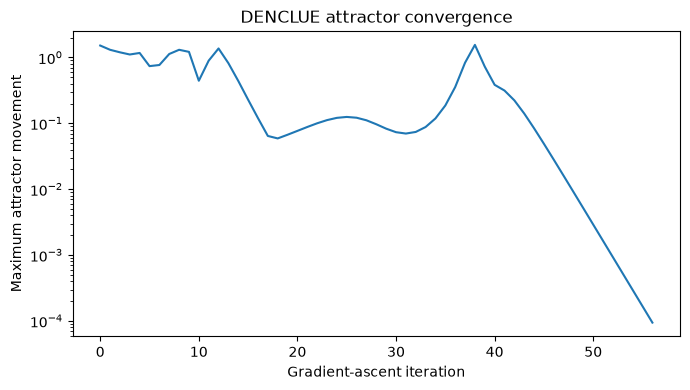

In [2]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import pairwise_distances

def gaussian_density(points, data, bandwidth):
    distances_sq = pairwise_distances(points, data, metric='sqeuclidean')
    return np.exp(-distances_sq / (2 * bandwidth ** 2)).mean(axis=1)

def density_attractors(data, bandwidth=1.5, tolerance=1e-4, max_iterations=300):
    attractors = data.copy()
    history = []

    for _ in range(max_iterations):
        distances_sq = pairwise_distances(attractors, data, metric='sqeuclidean')
        weights = np.exp(-distances_sq / (2 * bandwidth ** 2))
        updated = (weights @ data) / weights.sum(axis=1, keepdims=True)
        movement = np.linalg.norm(updated - attractors, axis=1).max()
        history.append(movement)
        attractors = updated
        if movement < tolerance:
            break

    return attractors, np.array(history)

bandwidth = 1.25
attractors, movement = density_attractors(X_scaled, bandwidth=bandwidth)
attractor_density = gaussian_density(attractors, X_scaled, bandwidth)

plt.figure(figsize=(7, 4))
plt.semilogy(movement)
plt.xlabel('Gradient-ascent iteration')
plt.ylabel('Maximum attractor movement')
plt.title('DENCLUE attractor convergence')
plt.tight_layout()
plt.show()


## Merge attractors and remove low-density points

Attractors closer than a tolerance belong to the same density-connected group. The density threshold $\xi$ distinguishes significant clusters from noise. These are modeling choices, so we inspect a bandwidth and threshold sensitivity table afterward.


DENCLUE: 3 clusters; 4 noise points
Adjusted Rand index: 0.796
Silhouette score: 0.29


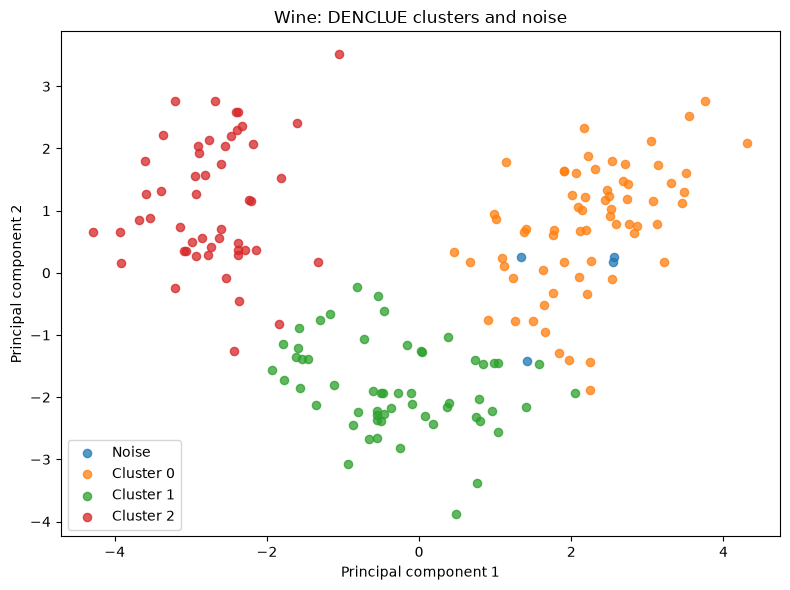

In [3]:
def denclue(data, bandwidth=1.25, density_threshold=None,
            attractor_tolerance=0.18, min_cluster_size=5):
    attractors, history = density_attractors(data, bandwidth=bandwidth)
    densities = gaussian_density(attractors, data, bandwidth)

    if density_threshold is None:
        density_threshold = np.quantile(densities, 0.10)

    significant = densities >= density_threshold
    labels = np.full(len(data), -1, dtype=int)

    # DBSCAN here only merges nearly identical density attractors.
    merged = DBSCAN(eps=attractor_tolerance, min_samples=1).fit_predict(attractors[significant])
    labels[significant] = merged

    # Small attractor groups are noise.
    for label in set(labels) - {-1}:
        if np.sum(labels == label) < min_cluster_size:
            labels[labels == label] = -1

    # Relabel retained clusters consecutively.
    retained = sorted(set(labels) - {-1})
    relabel = {old: new for new, old in enumerate(retained)}
    labels = np.array([relabel.get(label, -1) for label in labels])
    return labels, attractors, densities, history

denclue_labels, attractors, densities, history = denclue(
    X_scaled, bandwidth=1.25, attractor_tolerance=0.18
)
report_clustering(denclue_labels, 'DENCLUE')
plot_clusters(denclue_labels, 'Wine: DENCLUE clusters and noise')


## Parameter sensitivity

Increasing bandwidth smooths the density surface and tends to merge modes. Increasing the attractor-merging tolerance also tends to merge clusters. We compare several values without using the known class labels to fit any model.


In [4]:
results = []
for bandwidth in [1.0, 1.25, 1.5, 1.75, 2.0]:
    for tolerance in [0.10, 0.18, 0.30]:
        labels, _, _, _ = denclue(
            X_scaled, bandwidth=bandwidth, attractor_tolerance=tolerance
        )
        clustered = labels != -1
        n_clusters = len(set(labels[clustered]))
        silhouette = np.nan
        if n_clusters > 1 and clustered.sum() > n_clusters:
            silhouette = silhouette_score(X_scaled[clustered], labels[clustered])
        results.append((bandwidth, tolerance, n_clusters, (~clustered).sum(), silhouette))

print('bandwidth  merge_tol  clusters  noise  silhouette')
for bandwidth, tolerance, n_clusters, noise, silhouette in results:
    print(f'{bandwidth:9.2f}  {tolerance:9.2f}  {n_clusters:8d}  {noise:5d}  {silhouette:10.3f}')


bandwidth  merge_tol  clusters  noise  silhouette
     1.00       0.10         3     18       0.320
     1.00       0.18         3     18       0.320
     1.00       0.30         3     18       0.320
     1.25       0.10         3      4       0.290
     1.25       0.18         3      4       0.290
     1.25       0.30         3      4       0.290
     1.50       0.10         2      5       0.275
     1.50       0.18         2      5       0.275
     1.50       0.30         2      5       0.275
     1.75       0.10         1     18         nan
     1.75       0.18         1     18         nan
     1.75       0.30         1     18         nan
     2.00       0.10         1     18         nan
     2.00       0.18         1     18         nan
     2.00       0.30         1     18         nan


## Comparing density estimates in the PCA view

The model is fit in all 13 standardized dimensions. PCA is used only to display the resulting density values and labels.


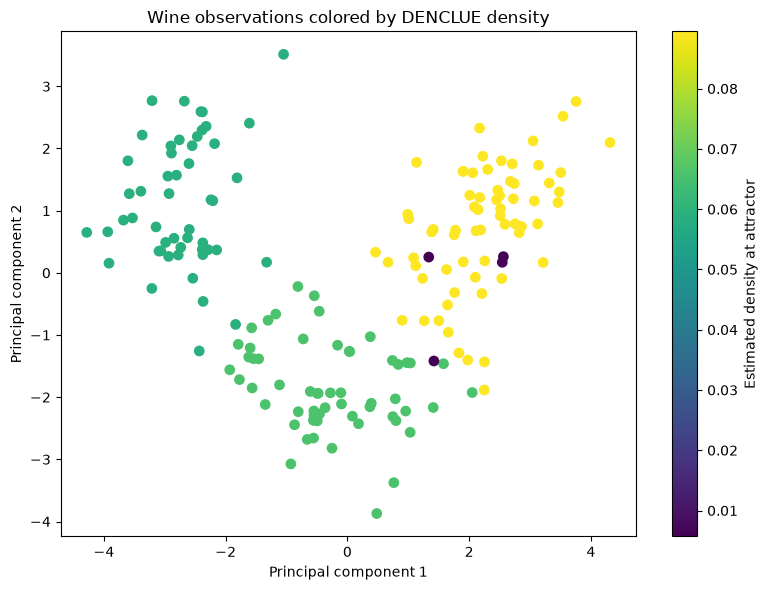

In [5]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_view[:, 0], X_view[:, 1], c=densities, cmap='viridis', s=45)
plt.colorbar(scatter, label='Estimated density at attractor')
plt.xlabel('Principal component 1')
plt.ylabel('Principal component 2')
plt.title('Wine observations colored by DENCLUE density')
plt.tight_layout()
plt.show()
